# KNN Regression Model

This notebook trains and evaluates a KNN Regression model with 10-fold cross-validation.

## 1. Setup & Imports

In [1]:
import sys
sys.path.append('..')

from src.data_loader import load_processed_data
from src.evaluation import perform_kfold_cv, calculate_metrics, save_results_json, create_results_dict
import time
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsRegressor

## 2. Load Preprocessed Data

In [2]:
print("Loading preprocessed data...")
X_train, X_test, y_train, y_test = load_processed_data()
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

Loading preprocessed data...
✓ Loaded processed data from data/processed/
  Train: (6766, 5), Test: (1692, 5)
Train set: (6766, 5), Test set: (1692, 5)


## 3. Feature Scaling

KNN Regression benefits from feature scaling.

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for consistency
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("✓ Features scaled")

✓ Features scaled


## 4. Model Configuration

In [4]:
model = KNeighborsRegressor(n_neighbors=5)
print(f"Model: {model}")

Model: KNeighborsRegressor()


## 5. Training

In [5]:
print("Training model...")
start_time = time.time()
model.fit(X_train_scaled, y_train)
training_time = time.time() - start_time
print(f"✓ Training completed in {training_time:.4f}s")

Training model...
✓ Training completed in 0.0057s


## 6. 10-Fold Cross-Validation

In [6]:
print("Performing 10-fold cross-validation...")
cv_results = perform_kfold_cv(model, X_train_scaled, y_train, k=10)
print(f"\nCV RMSE: {cv_results['rmse_mean']:.2f} ± {cv_results['rmse_std']:.2f}")
print(f"CV R²: {cv_results['r2_mean']:.4f} ± {cv_results['r2_std']:.4f}")

Performing 10-fold cross-validation...
Performing 10-fold cross-validation...
  Fold 1/10: RMSE=3934.52, R²=-0.0901
  Fold 2/10: RMSE=3911.46, R²=-0.0582
  Fold 3/10: RMSE=3478.49, R²=0.0272
  Fold 4/10: RMSE=3383.31, R²=-0.2030
  Fold 5/10: RMSE=4317.95, R²=0.0056
  Fold 6/10: RMSE=1497.33, R²=-0.4558
  Fold 7/10: RMSE=2807.01, R²=-0.1971
  Fold 8/10: RMSE=3216.94, R²=-0.3980
  Fold 9/10: RMSE=3187.97, R²=-0.0170
  Fold 10/10: RMSE=2935.64, R²=-0.4239

  CV Results:
    RMSE: 3267.06 ± 740.64
    R²:   -0.1810 ± 0.1763

CV RMSE: 3267.06 ± 740.64
CV R²: -0.1810 ± 0.1763


## 7. Test Set Evaluation

In [7]:
print("Evaluating on test set...")
y_pred = model.predict(X_test_scaled)
test_rmse, test_r2 = calculate_metrics(y_test, y_pred)
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test R²: {test_r2:.4f}")

Evaluating on test set...
Test RMSE: 2581.85
Test R²: -0.1201


## 8. Save Results to JSON

In [8]:
results = create_results_dict(
    algorithm="KNN Regression",
    model=model,
    X_train=X_train_scaled,
    cv_results=cv_results,
    test_scores={'rmse': float(test_rmse), 'r2': float(test_r2)},
    training_time=training_time
)

save_results_json(results, "04_knn.json")
print("✓ Results saved to ../results/04_knn.json")


✓ Results saved to results/04_knn.json
✓ Results saved to ../results/04_knn.json


## 9. Visualization

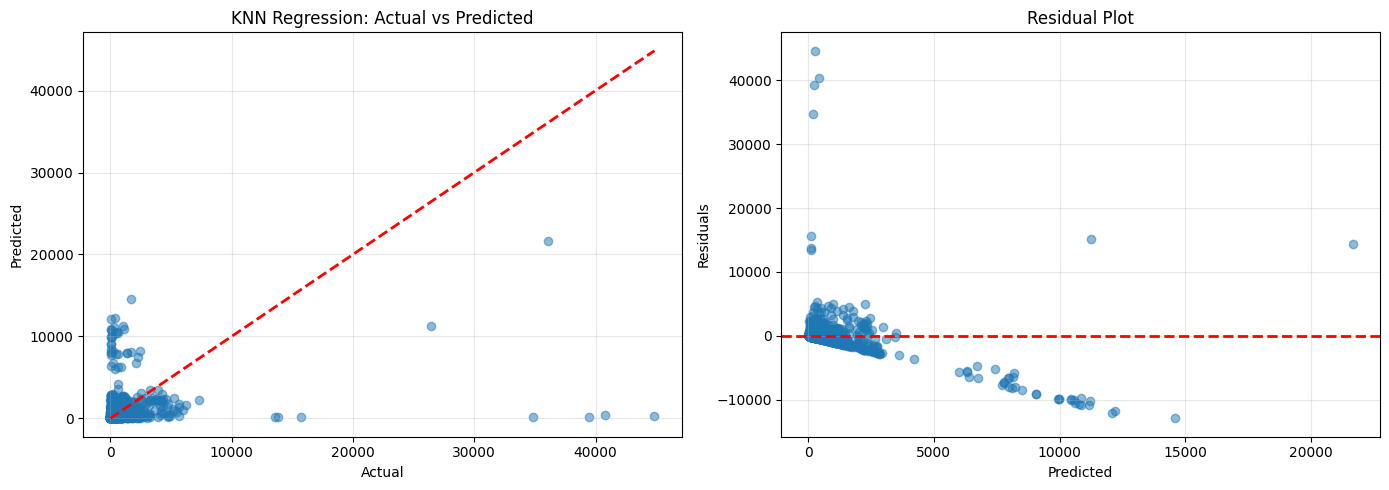

In [9]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('KNN Regression: Actual vs Predicted')
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
print("\n" + "="*60)
print("KNN MODEL COMPLETE!")
print("="*60)
print(f"CV RMSE: {cv_results['rmse_mean']:.2f} ± {cv_results['rmse_std']:.2f}")
print(f"CV R²: {cv_results['r2_mean']:.4f} ± {cv_results['r2_std']:.4f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test R²: {test_r2:.4f}")
print("="*60)


KNN MODEL COMPLETE!
CV RMSE: 3267.06 ± 740.64
CV R²: -0.1810 ± 0.1763
Test RMSE: 2581.85
Test R²: -0.1201
